In [1]:
# Install all required packages
!pip install pyspark==3.5.1 faker kafka-python pandas matplotlib seaborn plotly -q
print("✅ All packages installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 326.1/326.1 kB 19.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.
✅ All packages installed successfully!


In [2]:
import os
import random
import json
import time
import shutil
from datetime import datetime, timedelta
from pathlib import Path
from faker import Faker
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *

# Setup
BASE_DIR = Path("/content/spadex")
HDFS_ROOT = BASE_DIR / "hdfs_simulation"
HDFS_ROOT.mkdir(parents=True, exist_ok=True)
WAREHOUSE_DIR = HDFS_ROOT / "warehouse"
WAREHOUSE_DIR.mkdir(parents=True, exist_ok=True)

fake = Faker()
random.seed(42)
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Environment Setup Complete!")

✅ Environment Setup Complete!


In [4]:
import builtins

def generate_all_data():
    output_dir = HDFS_ROOT / "raw"
    output_dir.mkdir(parents=True, exist_ok=True)

    # Customers
    customers = []
    for i in range(1000):
        customers.append({
            "customer_id": i+1,
            "name": fake.name(),
            "city": fake.city(),
            "age": random.randint(18, 65),
            "registration_date": (datetime.now() - timedelta(days=random.randint(30, 1000))).strftime("%Y-%m-%d")
        })

    # Orders
    orders = []
    categories = ["Electronics", "Fashion", "Books", "Home", "Beauty"]
    for i in range(5000):
        orders.append({
            "order_id": i+1,
            "customer_id": random.randint(1, 1000),
            "order_date": (datetime.now() - timedelta(days=random.randint(0, 90))).strftime("%Y-%m-%d"),
            "amount": builtins.round(random.uniform(10, 500), 2),
            "category": random.choice(categories)
        })

    # Clickstream
    clickstream = []
    for i in range(8000):
        clickstream.append({
            "session_id": f"SES{random.randint(10000,99999)}",
            "customer_id": random.randint(1, 1000),
            "event": random.choice(["view", "click", "add_to_cart", "purchase"]),
            "timestamp": (datetime.now() - timedelta(minutes=random.randint(0, 1440))).isoformat(),
            "page": random.choice(["home", "product", "cart", "checkout"])
        })

    pd.DataFrame(customers).to_csv(output_dir / "customers.csv", index=False)
    pd.DataFrame(orders).to_csv(output_dir / "orders.csv", index=False)
    pd.DataFrame(clickstream).to_csv(output_dir / "clickstream.csv", index=False)

    print(f"✅ Data Generated Successfully in {output_dir}")
    return output_dir

generate_all_data()

✅ Data Generated Successfully in /content/spadex/hdfs_simulation/raw


PosixPath('/content/spadex/hdfs_simulation/raw')

In [6]:
# HDFS Simulation
def simulate_hdfs_put(local_path, hdfs_dest):
    src = Path(local_path)
    dest = HDFS_ROOT / hdfs_dest
    dest.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy(src, dest)
    print(f"📤 HDFS PUT: {src.name} → {hdfs_dest}")

raw_dir = HDFS_ROOT / "raw"
# Create a separate landing zone within HDFS_ROOT to simulate the 'put' operation to a new location
hdfs_landing_zone = HDFS_ROOT / "landing"
hdfs_landing_zone.mkdir(parents=True, exist_ok=True)

for file in raw_dir.glob("*.csv"):
    # Copy files from the 'raw' directory to the new 'landing' zone
    simulate_hdfs_put(file, f"landing/{file.name}")

📤 HDFS PUT: clickstream.csv → landing/clickstream.csv
📤 HDFS PUT: orders.csv → landing/orders.csv
📤 HDFS PUT: customers.csv → landing/customers.csv


In [7]:
# Spark Session
spark = SparkSession.builder \
    .appName("SpadeX_BigData_Pipeline") \
    .config("spark.sql.warehouse.dir", str(WAREHOUSE_DIR)) \
    .config("spark.executor.memory", "4g") \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")
print("🚀 Spark Session Created!")

🚀 Spark Session Created!


In [8]:
def run_spark_pipeline():
    orders = spark.read.csv(str(HDFS_ROOT / "raw/orders.csv"), header=True, inferSchema=True)
    customers = spark.read.csv(str(HDFS_ROOT / "raw/customers.csv"), header=True, inferSchema=True)

    # Customer 360
    customer_360 = orders.groupBy("customer_id").agg(
        sum("amount").alias("total_spend"),
        count("*").alias("total_orders"),
        max("order_date").alias("last_purchase_date")
    ).join(customers, "customer_id", "left")

    customer_360.write.mode("overwrite").parquet(str(HDFS_ROOT / "processed/customer360"))
    print("✅ Customer 360 View Created")

    # Monthly Revenue
    monthly = orders.withColumn("month", substring(col("order_date"), 1, 7)) \
        .groupBy("month", "category") \
        .agg(sum("amount").alias("revenue"), count("*").alias("order_count")) \
        .orderBy(desc("revenue"))
    monthly.write.mode("overwrite").csv(str(HDFS_ROOT / "reports/monthly_revenue"), header=True)
    print("✅ Monthly Revenue Report Generated")

    return customer_360, monthly

customer_360_df, monthly_df = run_spark_pipeline()

✅ Customer 360 View Created
✅ Monthly Revenue Report Generated


In [9]:
print("\n📡 Starting Spark Structured Streaming Simulation...")

# Schema for streaming data
schema = StructType([
    StructField("session_id", StringType(), True),
    StructField("customer_id", IntegerType(), True),
    StructField("event", StringType(), True),
    StructField("timestamp", TimestampType(), True),
    StructField("page", StringType(), True)
])

# Simulate streaming by writing clickstream in small batches
streaming_dir = HDFS_ROOT / "streaming_input"
streaming_dir.mkdir(parents=True, exist_ok=True)

def generate_stream_batch(batch_id):
    batch = []
    for _ in range(50):
        batch.append({
            "session_id": f"SES{random.randint(10000,99999)}",
            "customer_id": random.randint(1, 1000),
            "event": random.choice(["view", "click", "add_to_cart", "purchase"]),
            "timestamp": datetime.now(),
            "page": random.choice(["home", "product", "cart", "checkout"])
        })
    pd.DataFrame(batch).to_csv(streaming_dir / f"batch_{batch_id:03d}.csv", index=False)

# Generate 8 batches
for i in range(8):
    generate_stream_batch(i)
    time.sleep(0.5)

# Read as streaming
streaming_df = spark.readStream \
    .schema(schema) \
    .csv(str(streaming_dir), header=True)

# Real-time aggregation
realtime_agg = streaming_df \
    .groupBy(window(col("timestamp"), "5 minutes"), "event") \
    .count() \
    .orderBy("window")

# Write to console (you'll see live updates)
query = realtime_agg.writeStream \
    .outputMode("complete") \
    .format("console") \
    .option("truncate", False) \
    .start()

print("✅ Streaming Query Started! Check console for live updates.")
time.sleep(8)  # Let it run a bit
query.stop()
print("✅ Streaming Simulation Completed")


📡 Starting Spark Structured Streaming Simulation...
✅ Streaming Query Started! Check console for live updates.
✅ Streaming Simulation Completed



🎨 Generating Interactive Dashboard...


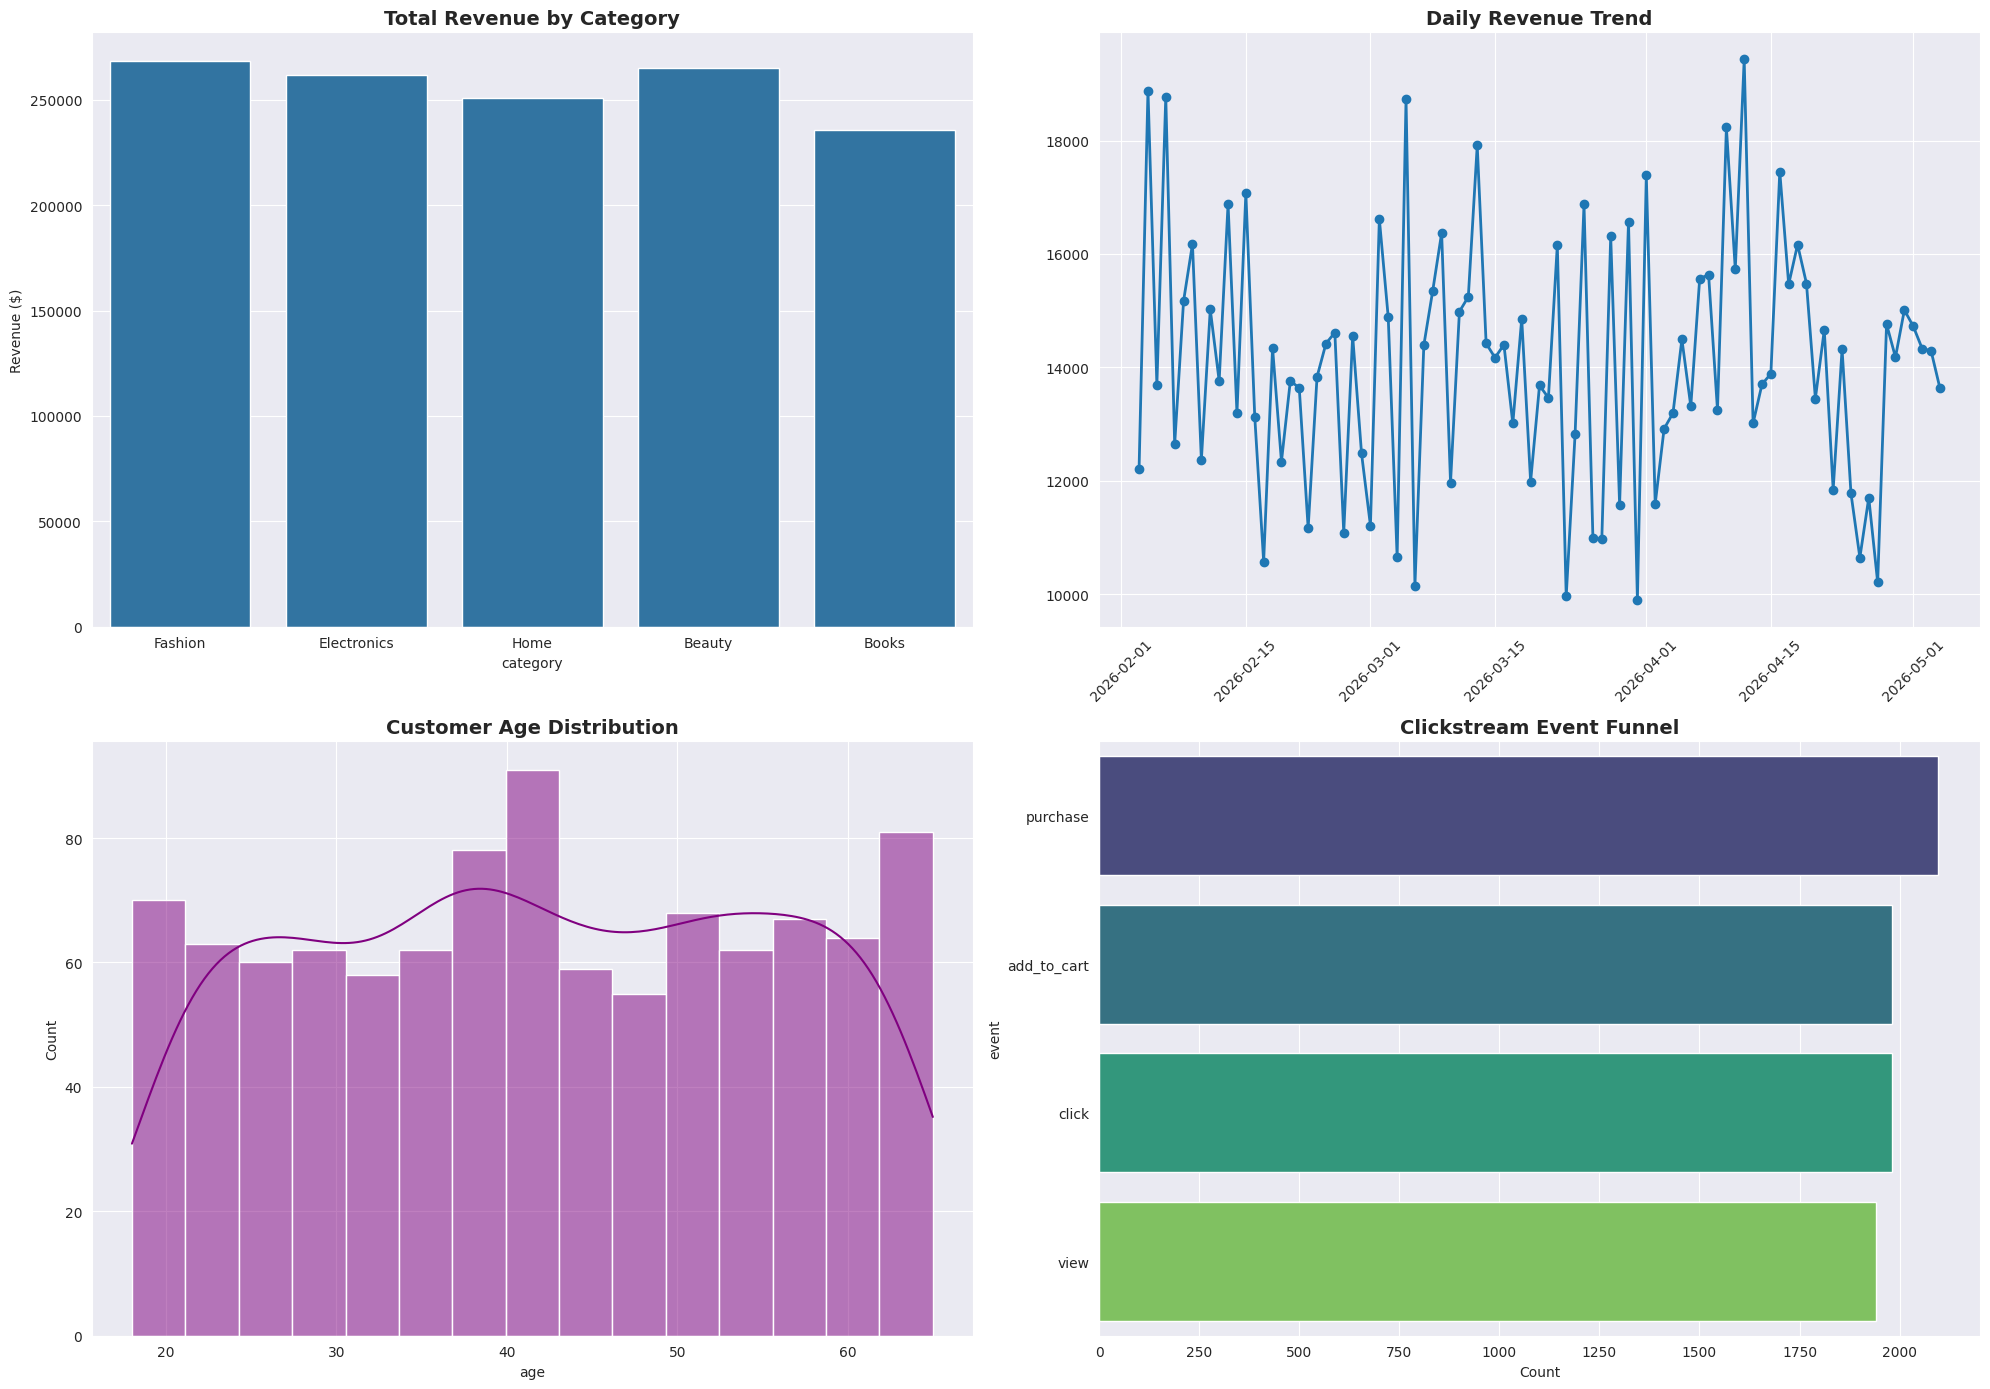


📊 KEY PERFORMANCE INDICATORS
Total Revenue       : $1,281,841.75
Total Orders        : 5,000
Unique Customers    : 992
Avg Order Value     : $256.37
Top Category        : Fashion


In [12]:
print("\n🎨 Generating Interactive Dashboard...")

# Load data into pandas for visualization
orders_pd = pd.read_csv(HDFS_ROOT / "raw/orders.csv")
customers_pd = pd.read_csv(HDFS_ROOT / "raw/customers.csv")
click_pd = pd.read_csv(HDFS_ROOT / "raw/clickstream.csv")

# === Dashboard Plots ===
fig = plt.figure(figsize=(20, 14))

# 1. Revenue by Category
plt.subplot(2, 2, 1)
sns.barplot(data=orders_pd, x='category', y='amount', estimator=builtins.sum, errorbar=None)
plt.title('Total Revenue by Category', fontsize=14, fontweight='bold')
plt.ylabel('Revenue ($)')

# 2. Orders Trend
plt.subplot(2, 2, 2)
orders_pd['order_date'] = pd.to_datetime(orders_pd['order_date'])
daily = orders_pd.groupby('order_date')['amount'].sum().reset_index()
plt.plot(daily['order_date'], daily['amount'], marker='o', linewidth=2)
plt.title('Daily Revenue Trend', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)

# 3. Customer Age Distribution
plt.subplot(2, 2, 3)
sns.histplot(customers_pd['age'], bins=15, kde=True, color='purple')
plt.title('Customer Age Distribution', fontsize=14, fontweight='bold')

# 4. Event Funnel
plt.subplot(2, 2, 4)
event_counts = click_pd['event'].value_counts()
sns.barplot(x=event_counts.values, y=event_counts.index, hue=event_counts.index, palette='viridis', legend=False)
plt.title('Clickstream Event Funnel', fontsize=14, fontweight='bold')
plt.xlabel('Count')

plt.tight_layout()
plt.show()

# Extra KPI Cards
print("\n" + "="*60)
print("📊 KEY PERFORMANCE INDICATORS")
print("="*60)
print(f"Total Revenue       : ${orders_pd['amount'].sum():,.2f}")
print(f"Total Orders        : {len(orders_pd):,}")
print(f"Unique Customers    : {orders_pd['customer_id'].nunique():,}")
print(f"Avg Order Value     : ${orders_pd['amount'].mean():.2f}")
print(f"Top Category        : {orders_pd.groupby('category')['amount'].sum().idxmax()}")
print("="*60)

In [13]:
# YARN, ZooKeeper, EMR, Kafka Simulation (same as before)
class YARNResourceManager:
    def __init__(self):
        self.jobs = {}
    def submit_job(self, job_name, job_type, vcores=4, memory=16):
        job_id = f"job_{len(self.jobs)+1:04d}"
        self.jobs[job_id] = {"name": job_name, "status": "RUNNING"}
        print(f"🚀 YARN Job Submitted → {job_id} | {job_name}")
        return job_id
    def complete_job(self, job_id):
        if job_id in self.jobs:
            self.jobs[job_id]["status"] = "SUCCEEDED"
            print(f"✅ YARN Job Completed → {job_id}")

yarn = YARNResourceManager()
job_id = yarn.submit_job("Spark_Customer360_Streaming", "SPARK", 8, 32)
yarn.complete_job(job_id)

print("\n🎉 SPADEX FULL PIPELINE WITH DASHBOARD + STREAMING EXECUTED SUCCESSFULLY!")

🚀 YARN Job Submitted → job_0001 | Spark_Customer360_Streaming
✅ YARN Job Completed → job_0001

🎉 SPADEX FULL PIPELINE WITH DASHBOARD + STREAMING EXECUTED SUCCESSFULLY!
